In [1]:
import ee
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("Device:", device)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("CUDA version:", torch.version.cuda)

Device: cuda
CUDA available: True
GPU name: NVIDIA GeForce RTX 5060 Ti
CUDA version: 12.8


In [2]:
import rasterio
import numpy as np

def load_raster(path):
    with rasterio.open(path) as src:
        data = src.read()
    X = data[:-1]
    y = data[-1]
    X = np.transpose(X, (1,2,0))
    return X, y

X_train_area, y_train_area = load_raster("Jabodetabek_West.tif")
X_val_area, y_val_area     = load_raster("Jabodetabek_Center.tif")
X_test_area, y_test_area   = load_raster("Jabodetabek_East.tif")


In [3]:
def extract_patches_fraction(X, y, patch_size=128, n_samples=3000):

    H, W, C = X.shape
    patches = []
    labels = []

    for _ in range(n_samples):

        i = np.random.randint(0, H - patch_size)
        j = np.random.randint(0, W - patch_size)

        patch = X[i:i+patch_size, j:j+patch_size]
        mask_patch = y[i:i+patch_size, j:j+patch_size]

        label = np.mean(mask_patch)

        patches.append(patch)
        labels.append(label)

    patches = np.array(patches)
    labels = np.array(labels)

    patches = np.transpose(patches, (0,3,1,2))  # (N,C,H,W)

    return patches, labels


X_train_p, y_train_p = extract_patches_fraction(X_train_area, y_train_area, 128, 3000)
X_val_p, y_val_p     = extract_patches_fraction(X_val_area, y_val_area, 128, 800)
X_test_p, y_test_p   = extract_patches_fraction(X_test_area, y_test_area, 128, 800)

In [4]:
means = X_train_p.mean(axis=(0,2,3))
stds  = X_train_p.std(axis=(0,2,3))

for c in range(7):
    X_train_p[:,c] = (X_train_p[:,c] - means[c]) / (stds[c] + 1e-6)
    X_val_p[:,c]   = (X_val_p[:,c]   - means[c]) / (stds[c] + 1e-6)
    X_test_p[:,c]  = (X_test_p[:,c]  - means[c]) / (stds[c] + 1e-6)

In [5]:
print("Train mean per channel:", X_train_p.mean(axis=(0,2,3)))
print("Train std per channel :", X_train_p.std(axis=(0,2,3)))


Train mean per channel: [ 0.38495955  0.4757158   0.361566    0.50047415  0.5102404   0.22569314
 -0.10096081]
Train std per channel : [0.9015117  0.8548827  0.907676   0.9422293  0.8911845  0.97054774
 0.9984435 ]


In [6]:
import torch
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(X_train_p, dtype=torch.float32)
X_val   = torch.tensor(X_val_p, dtype=torch.float32)
X_test  = torch.tensor(X_test_p, dtype=torch.float32)

y_train = torch.tensor(y_train_p, dtype=torch.float32)
y_val   = torch.tensor(y_val_p, dtype=torch.float32)
y_test  = torch.tensor(y_test_p, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=32, shuffle=True)

val_loader = DataLoader(TensorDataset(X_val, y_val),
                        batch_size=32, shuffle=False)

test_loader = DataLoader(TensorDataset(X_test, y_test),
                         batch_size=32, shuffle=False)

In [7]:
import torch.nn as nn

class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

In [8]:
class ResNetRegressor(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = ResidualBlock(7, 64)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        self.layer4 = ResidualBlock(256, 512, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        self.regressor = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        return self.regressor(x)

In [9]:
model = ResNetRegressor().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [10]:
import copy
import matplotlib.pyplot as plt
import numpy as np

num_epochs = 200
patience = 20
min_delta = 1e-4

best_loss = float("inf")
counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val Loss:   {val_loss:.6f}")
    print("-"*30)

    # ================= EARLY STOPPING =================
    if val_loss < best_loss - min_delta:
        best_loss = val_loss
        counter = 0
        best_weights = copy.deepcopy(model.state_dict())
        print("Best model updated")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

# Load best model
model.load_state_dict(best_weights)
print("Best model loaded.")

Epoch 1
Train Loss: 0.018097
Val Loss:   0.019570
------------------------------
Best model updated
Epoch 2
Train Loss: 0.005214
Val Loss:   0.034835
------------------------------
Epoch 3
Train Loss: 0.003701
Val Loss:   0.003643
------------------------------
Best model updated
Epoch 4
Train Loss: 0.003317
Val Loss:   0.003489
------------------------------
Best model updated
Epoch 5
Train Loss: 0.003196
Val Loss:   0.003558
------------------------------
Epoch 6
Train Loss: 0.002815
Val Loss:   0.005641
------------------------------
Epoch 7
Train Loss: 0.002258
Val Loss:   0.005997
------------------------------
Epoch 8
Train Loss: 0.001925
Val Loss:   0.008229
------------------------------
Epoch 9
Train Loss: 0.002288
Val Loss:   0.006515
------------------------------
Epoch 10
Train Loss: 0.001866
Val Loss:   0.002429
------------------------------
Best model updated
Epoch 11
Train Loss: 0.001948
Val Loss:   0.001571
------------------------------
Best model updated
Epoch 12
Tra

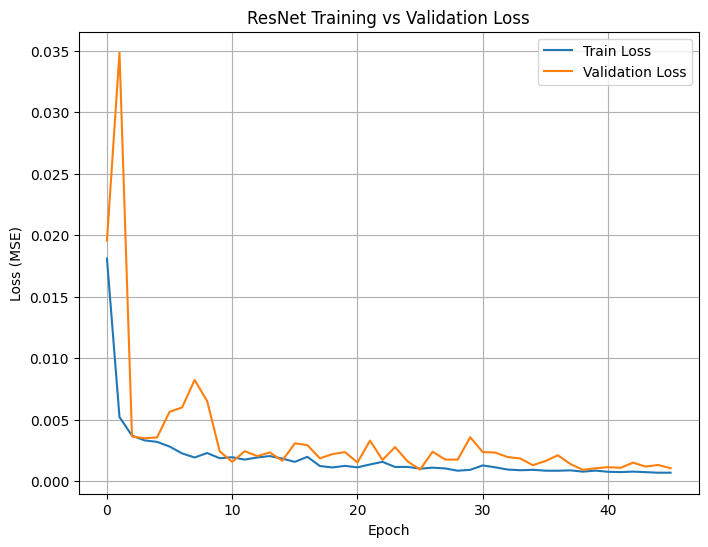

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(train_losses)
plt.plot(val_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("ResNet Training vs Validation Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.grid(True)

plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds.extend(outputs.cpu().numpy())

preds = np.array(preds).flatten()

mse  = mean_squared_error(y_test_p, preds)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_p, preds)
r2   = r2_score(y_test_p, preds)

print("Test MSE  :", mse)
print("Test RMSE :", rmse)
print("Test MAE  :", mae)
print("Test R2   :", r2)


print("Target range:", y_test_p.min(), "to", y_test_p.max())

Test MSE  : 0.0012323650298640132
Test RMSE : 0.035105057041173046
Test MAE  : 0.020981429144740105
Test R2   : 0.9597315788269043
Target range: 0.0 to 0.9094238


In [13]:
import numpy as np

truths = y_test.numpy()
baseline_mse = np.var(truths)

print("Baseline MSE:", baseline_mse)

Baseline MSE: 0.030603739


In [14]:
print("===== TRAIN =====")
print("Mean :", y_train.mean().item())
print("Std  :", y_train.std().item())
print("Var  :", y_train.var().item())

print("\n===== VALIDATION =====")
print("Mean :", y_val.mean().item())
print("Std  :", y_val.std().item())
print("Var  :", y_val.var().item())

print("\n===== TEST =====")
print("Mean :", y_test.mean().item())
print("Std  :", y_test.std().item())
print("Var  :", y_test.var().item())


===== TRAIN =====
Mean : 0.09062333405017853
Std  : 0.1721889078617096
Var  : 0.02964901737868786

===== VALIDATION =====
Mean : 0.28924188017845154
Std  : 0.3284851014614105
Var  : 0.10790245980024338

===== TEST =====
Mean : 0.10569068789482117
Std  : 0.17504867911338806
Var  : 0.030642041936516762


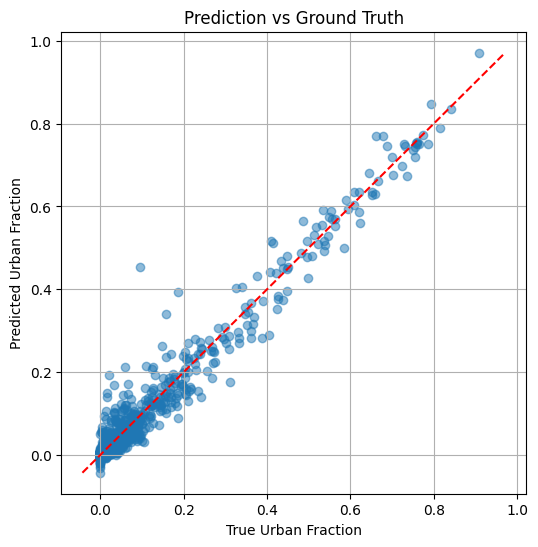

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_p, preds, alpha=0.5)

min_val = min(y_test_p.min(), preds.min())
max_val = max(y_test_p.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("True Urban Fraction")
plt.ylabel("Predicted Urban Fraction")
plt.title("Prediction vs Ground Truth")
plt.grid(True)
plt.show()


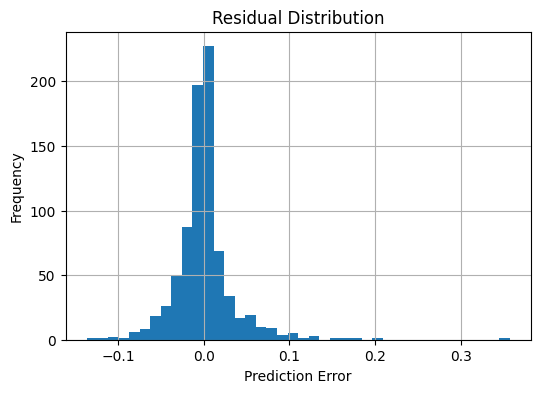

In [16]:
errors = preds - y_test_p

plt.figure(figsize=(6,4))
plt.hist(errors, bins=40)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(True)
plt.show()

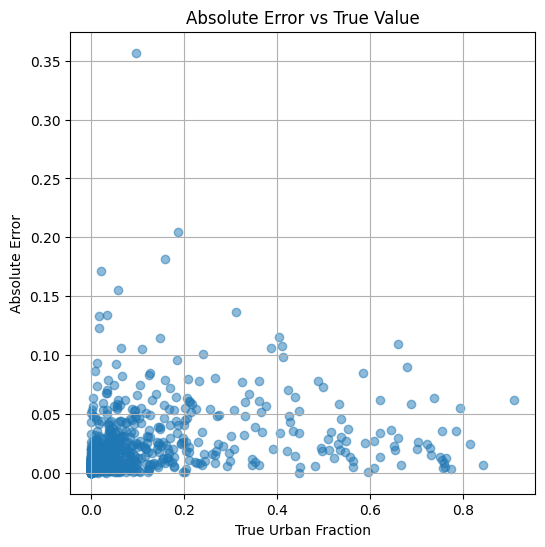

In [17]:
abs_error = np.abs(errors)

plt.figure(figsize=(6,6))
plt.scatter(y_test_p, abs_error, alpha=0.5)

plt.xlabel("True Urban Fraction")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs True Value")
plt.grid(True)
plt.show()